## TUGAS PEMROGRAMAN PARALEL 1

#### Nama           : Naila Faiza Inshyra
#### NIM            : 2411512013
#### Kelas          : Pemorograman Paralel A
#### Jurusan        : Teknik Komputer
#### Dosen Pengampu : Ibu Desta Yolanda

### SOAL NOMOR 1


### SOAL NOMOR 2

In [27]:
# JAWABAN NOMOR 2:
# 2.1 Hitung speedup teoritis untuk N = 2, 4, 8, 16, 32, 64 
import numpy as np
import matplotlib.pyplot as plt

def amdahl_speedup(P, N):
    return 1 / ((1 - P) + P / N)

# 1. Hitung speedup teoritis untuk N = 2, 4, 8, 16, 32, 64

P = 0.85
N = np.array([2, 4, 8, 16, 32, 64])
speedup = amdahl_speedup(P, N)

print("Hasil Speedup Teoritis")
print("======================")
for n, s in zip(N, speedup):
    print(f"N = {n:2d} -> Speedup = {s:.3f}")

print(f"Fungsi amdahl_speedup bisa langsung menerima array NumPy karena operasinya vectorized, yaitu satu instruksi diterapkan ke seluruh  elemen sekaligus (ini contoh dari kategori SIMD pada soal nomor 1).\n")


Hasil Speedup Teoritis
N =  2 -> Speedup = 1.739
N =  4 -> Speedup = 2.759
N =  8 -> Speedup = 3.902
N = 16 -> Speedup = 4.923
N = 32 -> Speedup = 5.664
N = 64 -> Speedup = 6.124
Fungsi amdahl_speedup bisa langsung menerima array NumPy karena operasinya vectorized, yaitu satu instruksi diterapkan ke seluruh  elemen sekaligus (ini contoh dari kategori SIMD pada soal nomor 1).



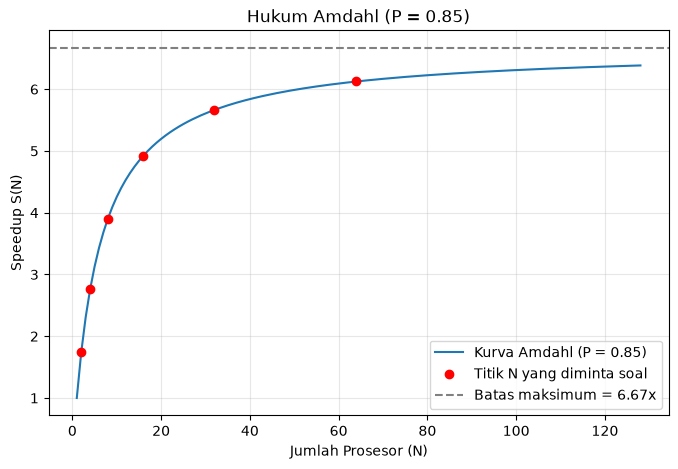


Garis putus-putus abu-abu adalah plafon speedup. Terlihat kurvanya mendatar (saturasi) walaupun jumlah prosesor terus bertambah — persis seperti demo Hukum Amdahl pada Pertemuan 4.


In [30]:
# 2.2 Buat plot speedup vs N

S_max = 1 / (1 - P)     # batas atas speedup saat N -> tak hingga
N_halus = np.arange(1, 129)

plt.figure(figsize=(8, 5))
plt.plot(N_halus, amdahl_speedup(P, N_halus), label=f"Kurva Amdahl (P = {P})")
plt.plot(N, speedup, marker='o', linestyle='none', color='red',
         label="Titik N yang diminta soal")
plt.axhline(S_max, linestyle='--', color='gray',
            label=f"Batas maksimum = {S_max:.2f}x")
plt.title("Hukum Amdahl (P = 0.85)")
plt.xlabel("Jumlah Prosesor (N)")
plt.ylabel("Speedup S(N)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print (f"\nGaris putus-putus abu-abu adalah plafon speedup. Terlihat kurvanya mendatar (saturasi) walaupun jumlah prosesor terus bertambah — persis seperti demo Hukum Amdahl pada Pertemuan 4.")


In [31]:
# 2.3 Analisis diminishing returns dan uji pengandaan prosesor
print("Analisis Diminishing Returns")
print("============================")
print(f"{'N':>4} | {'S(N)':>7} | {'Kenaikan dari N sebelumnya':>27} | {'Efisiensi S/N':>13}")
print("-" * 62)

sebelumnya = 1.0                      # S(1) = 1
for n, s in zip(N, speedup):
    print(f"{n:>4} | {s:>6.3f}x | {s - sebelumnya:>26.3f} | {s/n:>12.1%}")
    sebelumnya = s

# Menghitung speedup maksimum teoritis
print(f"\nSpeedup maksimum teoritis = {S_max:.3f}")

ambang = 0.05 * S_max

print(f"Ambang manfaat (5% dari S_max = {S_max:.2f}x) = {ambang:.3f}x\n")
print(f"{'N':>4} -> {'2N':>4} | {'Kenaikan S':>11} | Keterangan")
print("-" * 52)

for n in [1, 2, 4, 8, 16, 32, 64, 128]:
    kenaikan = amdahl_speedup(P, 2 * n) - amdahl_speedup(P, n)
    status = "masih signifikan" if kenaikan >= ambang else "sudah sangat kecil"
    print(f"{n:>4} -> {2*n:>4} | {kenaikan:>10.3f}x | {status}")

print(f"\nBerdasarkan hasil perhitungan, speedup masih meningkat ketika jumlah prosesor ditambah, tetapi peningkatannya mulai semakin kecil pada N = 16 dan semakin terlihat pada N = 32–64. Hal ini dapat dilihat dari kenaikan speedup yang menurun, yaitu 1,021x dari 8→16, 0,741x dari 16→32, dan 0,461x dari 32→64, serta efisiensi yang turun hingga 9,6% pada 64 prosesor. Kondisi ini terjadi karena terdapat 15% bagian program yang bersifat serial sehingga tidak dapat diparalelkan. Dengan speedup maksimum teoritis sebesar 6,667x, penambahan prosesor setelah jumlah tertentu semakin kurang memberikan manfaat.")

Analisis Diminishing Returns
   N |    S(N) |  Kenaikan dari N sebelumnya | Efisiensi S/N
--------------------------------------------------------------
   2 |  1.739x |                      0.739 |        87.0%
   4 |  2.759x |                      1.019 |        69.0%
   8 |  3.902x |                      1.144 |        48.8%
  16 |  4.923x |                      1.021 |        30.8%
  32 |  5.664x |                      0.741 |        17.7%
  64 |  6.124x |                      0.461 |         9.6%

Speedup maksimum teoritis = 6.667
Ambang manfaat (5% dari S_max = 6.67x) = 0.333x

   N ->   2N |  Kenaikan S | Keterangan
----------------------------------------------------
   1 ->    2 |      0.739x | masih signifikan
   2 ->    4 |      1.019x | masih signifikan
   4 ->    8 |      1.144x | masih signifikan
   8 ->   16 |      1.021x | masih signifikan
  16 ->   32 |      0.741x | masih signifikan
  32 ->   64 |      0.461x | masih signifikan
  64 ->  128 |      0.260x | sudah sanga

### SOAL NOMOR 3

In [6]:
! pip install pandas

   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/10.0 MB 283.6 kB/s eta 0:00:34
   -- ------------------------------------- 0.5/10.0 MB 283.6 kB/s eta 0:00:34
   -- ------------------------------------- 0.5/10.0 MB 283.6 kB/s eta 0:00:34
   -- ------------------------------------- 0.5/10.0 MB 283.6 k

N =  10,000 -> Ditemukan  1,229 prima -> Waktu = 0.0078 detik
N =  20,000 -> Ditemukan  2,262 prima -> Waktu = 0.0283 detik
N =  40,000 -> Ditemukan  4,203 prima -> Waktu = 0.0566 detik
N =  80,000 -> Ditemukan  7,837 prima -> Waktu = 0.1248 detik
N = 160,000 -> Ditemukan 14,683 prima -> Waktu = 0.3314 detik


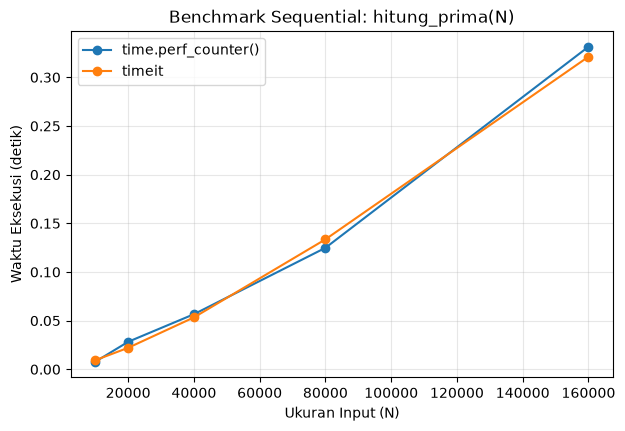

In [24]:
# JAWABAN SOAL NOMOR 3
import time
import timeit
import pandas as pd
import matplotlib.pyplot as plt

# Fungsi untuk menghitung semua bilangan prima hingga n
def hitung_prima(n):
    primes = []
    for num in range(2, n):
        is_prime = True
        for i in range(2, int(num ** 0.5) + 1):
            if num % i == 0:
                is_prime = False
                break
        if is_prime:
            primes.append(num)
    return primes

# ------------------------------------------------------------
# 1. Menentukan ukuran input
# ------------------------------------------------------------
ukuran_input = [10_000, 20_000, 40_000, 80_000, 160_000]

# ------------------------------------------------------------
# 2. Pengukuran menggunakan time.perf_counter()
# ------------------------------------------------------------
waktu_perf_counter = []
for n in ukuran_input:
    start = time.perf_counter()
    hasil = hitung_prima(n)
    end = time.perf_counter()
    waktu = end - start
    waktu_perf_counter.append(waktu)
    print(
        f"N = {n:>7,} -> "
        f"Ditemukan {len(hasil):>6,} prima -> "
        f"Waktu = {waktu:.4f} detik"
    )

# ------------------------------------------------------------
# 3. Pengukuran menggunakan timeit
# ------------------------------------------------------------
waktu_timeit = []
for n in ukuran_input:
    waktu = timeit.timeit(
        lambda: hitung_prima(n),
        number=3
    ) / 3
    waktu_timeit.append(waktu)

# ------------------------------------------------------------
# 4. Membuat tabel perbandingan
# ------------------------------------------------------------
tabel_benchmark = pd.DataFrame({
    "Ukuran Input (N)": ukuran_input,
    "perf_counter (detik)": waktu_perf_counter,
    "timeit (detik)": waktu_timeit
})
tabel_benchmark

# ------------------------------------------------------------
# 5. Membuat plot perbandingan perf_counter dan timeit
# ------------------------------------------------------------
plt.figure(figsize=(7, 4.5))

plt.plot(
    ukuran_input,
    waktu_perf_counter,
    marker='o',
    label='time.perf_counter()'
)
plt.plot(
    ukuran_input,
    waktu_timeit,
    marker='o',
    label='timeit'
)
plt.title("Benchmark Sequential: hitung_prima(N)")
plt.xlabel("Ukuran Input (N)")
plt.ylabel("Waktu Eksekusi (detik)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### SOAL NOMOR 4